In [17]:
# Cell 1: Imports & Configuration
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from google.oauth2.service_account import Credentials
from googleapiclient.discovery import build

# Google Sheets Configuration
CREDENTIALS_FILE = 'credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets.readonly']
SPREADSHEET = 'https://docs.google.com/spreadsheets/d/1_W02gvDzfiVHnTSk2vNilGeHzwi1l1Z3fs_DYlm1tVY/edit'
SHEET_NAMES = ['Functional']  # Add more sheet names to process multiple tabs

# Testing/Display Configuration
FILL_MISSING_WITH_RANDOM = True  # Set True to fill NaN with random 1-5 values for testing
RANDOM_SEED = 42  # For reproducibility when filling random data

# Plotly renderer
pio.renderers.default = "notebook"

In [18]:
# Cell 2: Utility Functions

def extract_spreadsheet_id(url_or_id):
    """Extract spreadsheet ID from full URL or return as-is if already an ID."""
    if 'docs.google.com' in url_or_id:
        parts = url_or_id.split('/d/')
        if len(parts) > 1:
            return parts[1].split('/')[0]
    return url_or_id

def read_google_sheet(spreadsheet_id, sheet_name=None):
    """Read raw data from Google Sheet. Returns (fields, headers, data) tuple."""
    spreadsheet_id = extract_spreadsheet_id(spreadsheet_id)
    creds = Credentials.from_service_account_file(CREDENTIALS_FILE, scopes=SCOPES)
    service = build('sheets', 'v4', credentials=creds)
    
    range_name = sheet_name if sheet_name else 'Sheet1'
    result = service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    
    values = result.get('values', [])
    if not values:
        print('No data found in sheet.')
        return None, None, None
    
    # Row 0: field names (merged cells - some will be empty)
    # Row 1: individual column headers
    # Row 2+: data
    field_row = values[0]
    header_row = values[1]
    
    # Forward-fill the field names to expand merged cells
    current_field = ''
    fields = []
    for cell in field_row:
        if cell.strip():
            current_field = cell.strip()
        fields.append(current_field)
    
    return fields, header_row, values[2:]

def get_unique_fields(score_fields):
    """Extract unique field names preserving order."""
    unique = []
    for f in score_fields:
        if f and f not in unique:
            unique.append(f)
    return unique

def parse_sheet_data(fields, headers, data, fill_random=False, random_seed=42):
    """
    Parse sheet data into stats DataFrame.
    
    Args:
        fields: List of field names (from merged header row)
        headers: List of column headers
        data: Raw data rows
        fill_random: If True, fill NaN values with random 1-5 values
        random_seed: Seed for reproducibility
    
    Returns:
        stats_df: DataFrame with Avg/Std/Min/Max per field, indexed by row ID
        unique_fields: List of unique field names
    """
    if fill_random:
        np.random.seed(random_seed)
    
    num_cols = len(headers)
    
    # Extract row IDs and normalize data
    normalized_data = []
    row_ids = []
    for row in data:
        if len(row) > 0:
            row_ids.append(row[0])
            row_data = row[1:] if len(row) > 1 else []
            if len(row_data) >= num_cols - 1:
                normalized_data.append(row_data[:num_cols - 1])
            else:
                normalized_data.append(row_data + [''] * (num_cols - 1 - len(row_data)))
    
    # Create DataFrame and convert to numeric
    df = pd.DataFrame(normalized_data)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Optionally fill NaN with random values
    if fill_random:
        mask = df.isna()
        random_values = np.random.uniform(1, 5, size=df.shape)
        df = df.fillna(pd.DataFrame(random_values, columns=df.columns))
    
    # Map column indices to field names (excluding column A)
    score_fields = fields[1:]
    field_to_cols = {}
    for idx, field in enumerate(score_fields):
        if field not in field_to_cols:
            field_to_cols[field] = []
        field_to_cols[field].append(idx)
    
    unique_fields = get_unique_fields(score_fields)
    
    # Calculate stats for each row and field
    stats_rows = []
    for row_idx, row_id in enumerate(row_ids):
        row_stats = {}
        for field in unique_fields:
            col_indices = field_to_cols[field]
            values = df.iloc[row_idx, col_indices].values
            values = values[~np.isnan(values)]
            if len(values) > 0:
                row_stats[f'{field}_Avg'] = np.mean(values)
                row_stats[f'{field}_Std'] = np.std(values)
                row_stats[f'{field}_Min'] = np.min(values)
                row_stats[f'{field}_Max'] = np.max(values)
            else:
                row_stats[f'{field}_Avg'] = np.nan
                row_stats[f'{field}_Std'] = np.nan
                row_stats[f'{field}_Min'] = np.nan
                row_stats[f'{field}_Max'] = np.nan
        stats_rows.append(row_stats)
    
    stats_df = pd.DataFrame(stats_rows, index=row_ids)
    stats_df.index.name = 'Row'
    
    return stats_df, unique_fields

In [19]:
# Cell 3: Plotting Functions

def plot_radar_matplotlib(stats_df, unique_fields, title='Field Averages'):
    """Create matplotlib radar plot showing averages."""
    categories = unique_fields
    num_categories = len(categories)
    
    angles = np.linspace(0, 2 * np.pi, num_categories, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
    
    for row_label, row in stats_df.iterrows():
        values = [row[f'{field}_Avg'] for field in unique_fields]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row_label)
        ax.fill(angles, values, alpha=0.05)
    
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0, 6)
    ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
    
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}_matplotlib.png', bbox_inches='tight')
    plt.show()

def plot_radar_with_ranges_matplotlib(stats_df, unique_fields, title='Field Ranges (±1 Std Dev)'):
    """Create matplotlib radar plot showing avg line with ±1 std shaded range."""
    categories = unique_fields
    num_categories = len(categories)
    
    angles = np.linspace(0, 2 * np.pi, num_categories, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(polar=True))
    
    # Color cycle
    colors = plt.cm.tab10.colors
    
    for idx, (row_label, row) in enumerate(stats_df.iterrows()):
        color = colors[idx % len(colors)]
        
        # Get avg and std values
        avg_vals = [row[f'{field}_Avg'] for field in unique_fields]
        std_vals = [row[f'{field}_Std'] for field in unique_fields]
        
        # Calculate bounds
        upper_vals = [avg + std for avg, std in zip(avg_vals, std_vals)]
        lower_vals = [max(0, avg - std) for avg, std in zip(avg_vals, std_vals)]
        
        # Close the shapes
        avg_vals_closed = avg_vals + [avg_vals[0]]
        upper_vals_closed = upper_vals + [upper_vals[0]]
        lower_vals_closed = lower_vals + [lower_vals[0]]
        
        # Plot shaded band between lower and upper
        ax.fill(angles, upper_vals_closed, alpha=0.15, color=color)
        ax.fill(angles, lower_vals_closed, alpha=1.0, color='white')  # Cut out inner
        ax.plot(angles, upper_vals_closed, '--', linewidth=1, color=color, alpha=0.5)
        ax.plot(angles, lower_vals_closed, '--', linewidth=1, color=color, alpha=0.5)
        
        # Plot average line on top
        ax.plot(angles, avg_vals_closed, 'o-', linewidth=2, color=color, label=row_label)
    
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0, 6)
    ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))
    
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}_matplotlib.png', bbox_inches='tight')
    plt.show()

def plot_radar_plotly(stats_df, unique_fields, title='Field Averages'):
    """Create Plotly radar plot showing averages."""
    fig = go.Figure()
    
    for row_label, row in stats_df.iterrows():
        values = [row[f'{field}_Avg'] for field in unique_fields]
        values += values[:1]
        
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=unique_fields + [unique_fields[0]],
            name=row_label,
            fill='toself',
            opacity=0.6
        ))
    
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 6])),
        showlegend=True,
        title=title,
        width=900,
        height=700
    )
    
    fig.write_html(f'{title.replace(" ", "_").lower()}_plotly.html')
    print(f"Saved to {title.replace(' ', '_').lower()}_plotly.html")
    fig.show()

def plot_radar_with_ranges_plotly(stats_df, unique_fields, title='Field Ranges (±1 Std Dev)'):
    """
    Create Plotly radar plot showing avg line with ±1 standard deviation shaded range per row.
    Each row gets a shaded band (mean-std to mean+std) with the average line on top.
    """
    fig = go.Figure()
    
    # Color palette for different rows
    colors = [
        'rgba(31, 119, 180, {})',   # blue
        'rgba(255, 127, 14, {})',   # orange
        'rgba(44, 160, 44, {})',    # green
        'rgba(214, 39, 40, {})',    # red
        'rgba(148, 103, 189, {})',  # purple
        'rgba(140, 86, 75, {})',    # brown
        'rgba(227, 119, 194, {})',  # pink
        'rgba(127, 127, 127, {})',  # gray
        'rgba(188, 189, 34, {})',   # olive
        'rgba(23, 190, 207, {})',   # cyan
    ]
    
    theta = unique_fields + [unique_fields[0]]
    
    for idx, (row_label, row) in enumerate(stats_df.iterrows()):
        color_template = colors[idx % len(colors)]
        
        # Get avg and std values, calculate ±1 std bounds
        avg_vals = [row[f'{field}_Avg'] for field in unique_fields]
        std_vals = [row[f'{field}_Std'] for field in unique_fields]
        
        # Calculate upper and lower bounds (mean ± 1 std)
        upper_vals = [avg + std for avg, std in zip(avg_vals, std_vals)]
        lower_vals = [max(0, avg - std) for avg, std in zip(avg_vals, std_vals)]  # Clamp to 0
        
        # Close the shapes
        lower_vals_closed = lower_vals + [lower_vals[0]]
        avg_vals_closed = avg_vals + [avg_vals[0]]
        upper_vals_closed = upper_vals + [upper_vals[0]]
        
        # Add upper boundary (outer edge of band)
        fig.add_trace(go.Scatterpolar(
            r=upper_vals_closed,
            theta=theta,
            name=f'{row_label} (+1σ)',
            line=dict(color=color_template.format(0.3), width=1),
            showlegend=False,
        ))
        
        # Add lower boundary with fill to previous (creates the band)
        fig.add_trace(go.Scatterpolar(
            r=lower_vals_closed,
            theta=theta,
            name=f'{row_label} (-1σ)',
            fill='tonext',
            fillcolor=color_template.format(0.2),
            line=dict(color=color_template.format(0.3), width=1),
            showlegend=False,
        ))
        
        # Add average line on top
        fig.add_trace(go.Scatterpolar(
            r=avg_vals_closed,
            theta=theta,
            name=row_label,
            mode='lines+markers',
            line=dict(color=color_template.format(1.0), width=2),
            marker=dict(size=6, color=color_template.format(1.0)),
        ))
    
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 6])),
        showlegend=True,
        title=title,
        width=1000,
        height=800
    )
    
    fig.write_html(f'{title.replace(" ", "_").lower()}_ranges.html')
    print(f"Saved to {title.replace(' ', '_').lower()}_ranges.html")
    fig.show()

In [20]:
# Cell 4: Data Loading
# Process the first sheet (or loop through SHEET_NAMES for multiple)

sheet_name = SHEET_NAMES[0]  # Use first sheet; modify to loop for multiple
print(f"Loading sheet: {sheet_name}")

fields, headers, data = read_google_sheet(SPREADSHEET, sheet_name)
stats_df, unique_fields = parse_sheet_data(
    fields, headers, data,
    fill_random=FILL_MISSING_WITH_RANDOM,
    random_seed=RANDOM_SEED
)

print(f"Unique fields: {unique_fields}")
print(f"Stats shape: {stats_df.shape}")
stats_df

Loading sheet: Functional
Unique fields: ['Scalability', 'Throughput', 'Isolation', 'Density', 'Peerability', 'HW Capital', 'Button pushing VM admin friendliness TODAY']
Stats shape: (10, 28)


,Scalability_Avg,Scalability_Std,Scalability_Min,Scalability_Max,Throughput_Avg,Throughput_Std,Throughput_Min,Throughput_Max,Isolation_Avg,Isolation_Std,...,Peerability_Min,Peerability_Max,HW Capital_Avg,HW Capital_Std,HW Capital_Min,HW Capital_Max,Button pushing VM admin friendliness TODAY_Avg,Button pushing VM admin friendliness TODAY_Std,Button pushing VM admin friendliness TODAY_Min,Button pushing VM admin friendliness TODAY_Max
Row,,,,,,,,,,,,,,,,,,,,,
Namespace based isolation,4.243611,0.396538,3.927976,4.802857,1.749351,0.177236,1.623978,2.000000,2.956388,1.449510,...,1.000000,1.849356,2.105332,0.860552,1.000000,3.099026,4.0,0.0,4.0,4.0
Manual NADs with MAC-VLAN,1.878009,0.632565,1.000000,2.465447,3.313133,1.072409,1.798695,4.140704,2.851820,1.205832,...,3.000000,4.862528,3.042540,1.172963,1.390688,4.000000,1.0,0.0,1.0,1.0
Localnets,3.224134,1.074085,2.035120,4.637282,2.775705,0.375394,2.246844,3.080272,3.539252,1.322226,...,1.353970,4.687497,1.827410,0.473407,1.180909,2.301321,4.0,0.0,4.0,4.0
UDNs (Just NAT),2.764841,0.458658,2.123738,3.170784,2.502330,1.240196,1.298203,4.208788,2.627947,1.036494,...,1.000000,4.085081,2.305297,1.529986,1.000000,4.452414,5.0,0.0,5.0,5.0
UDN + BGP,3.073053,0.662437,2.300733,3.918425,3.145904,1.056319,2.000000,4.548851,3.632040,0.453612,...,1.101677,2.710164,2.223786,1.000523,1.125717,3.545642,3.0,0.0,3.0,3.0
UDN + BGP + EgressIP,2.887912,0.843744,2.000000,4.022205,1.822308,0.369475,1.307920,2.159006,3.983757,0.723398,...,2.000000,4.570236,2.952126,1.159497,2.000000,4.584365,2.0,0.0,2.0,2.0
VRF-Lite peering,3.156910,1.516322,1.027809,4.442922,2.519358,0.466073,1.888431,3.000000,3.707367,1.009869,...,4.000000,4.887128,2.730836,0.372900,2.203513,3.000000,1.0,0.0,1.0,1.0
BGP-eVPN (assumed no overlay),2.440167,1.163681,1.205915,4.000000,2.512609,1.063045,1.579579,4.000000,3.636941,1.241127,...,2.471133,5.000000,2.834753,1.099145,1.361159,4.000000,1.0,0.0,1.0,1.0
DPU in trusted mode,3.691276,0.260167,3.363572,4.000000,3.318118,1.277447,1.905983,5.000000,2.820406,0.853063,...,1.453894,4.698774,3.557234,1.213186,2.031767,5.000000,1.0,0.0,1.0,1.0


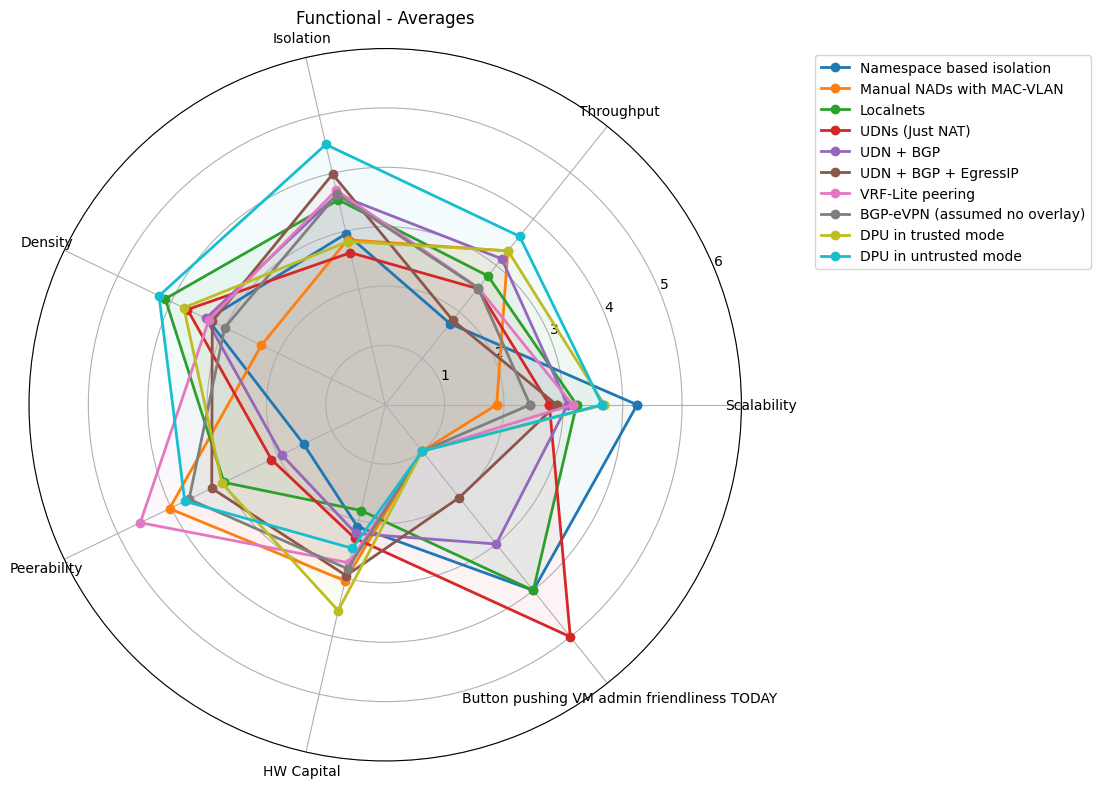

In [21]:
# Cell 5: Matplotlib Radar Plot (Averages)
plot_radar_matplotlib(stats_df, unique_fields, title=f'{sheet_name} - Averages')

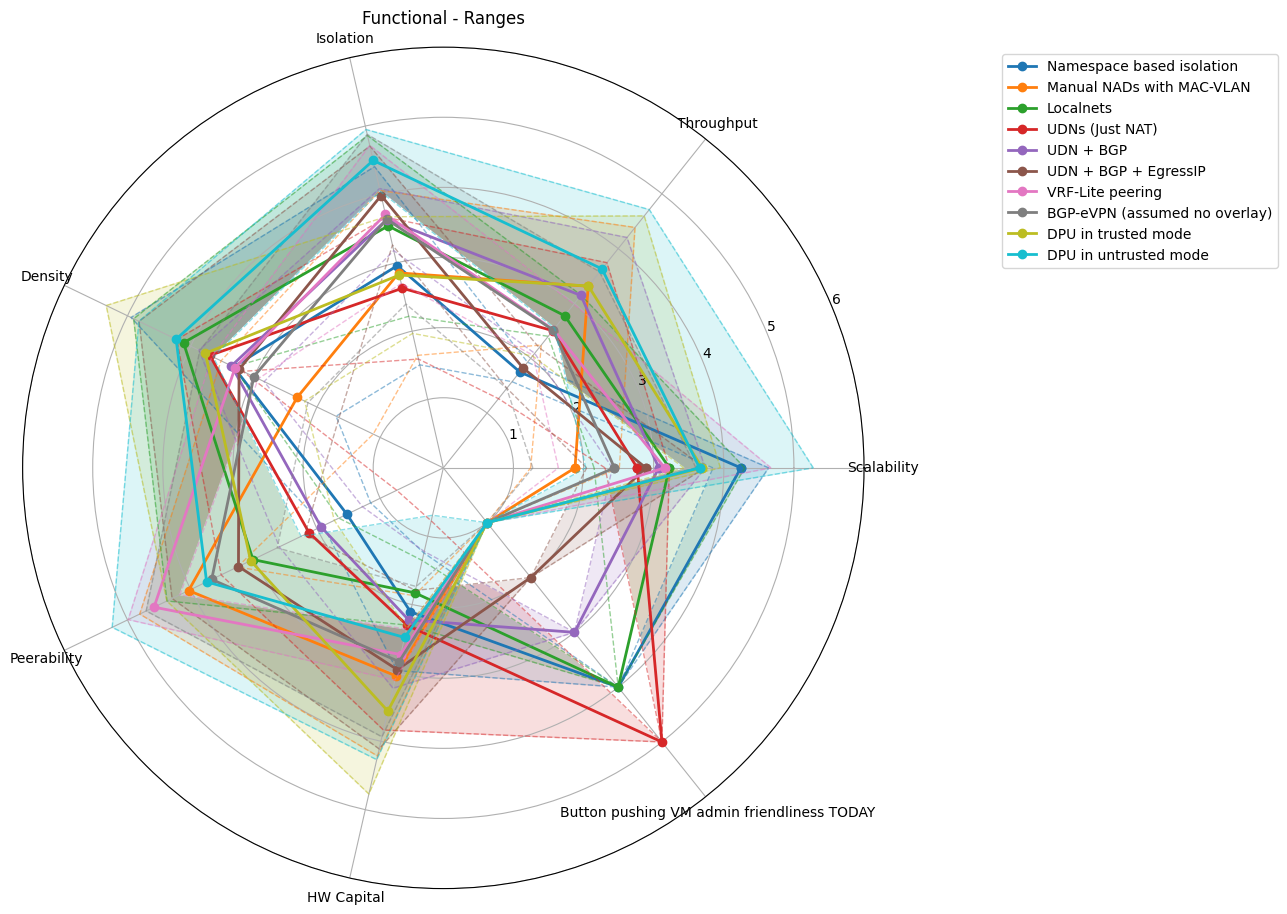

In [22]:
# Cell 5b: Matplotlib Radar Plot with Ranges (±1 Std Dev)
plot_radar_with_ranges_matplotlib(stats_df, unique_fields, title=f'{sheet_name} - Ranges')

In [23]:
# Cell 6: Plotly Radar Plot (Averages)
plot_radar_plotly(stats_df, unique_fields, title=f'{sheet_name} - Averages')

Saved to functional_-_averages_plotly.html


In [24]:
# Cell 7: Plotly Radar Plot with Min-Max Ranges
plot_radar_with_ranges_plotly(stats_df, unique_fields, title=f'{sheet_name} - Ranges')

Saved to functional_-_ranges_ranges.html
